In [ ]:
import uproot
import matplotlib.pyplot as plt
import numpy as np
import compress_pickle as pickle  
import mplhep as hep
import math
from scipy.optimize import curve_fit
import compress_pickle
import pickle
import gzip
hep.style.use("CMS")
from helpers import *

In [ ]:
path_to_result = "/media/miguel/Elements_2024/AI_data/results_and_models/ePIC_DIS_results/testing_new_output_singleneutron/"

In [ ]:
particle ='neutron'  # pi+,  pi0, neutron, gamma
input_features='4D'  ## input features [4D, 2D, 1D]
output_dim='3D'    ## '1D', '2D', '3D'
theta_low=1.273
theta_high=5.7
granularity='high_granularity'
already_rotated=False
date = "August 2025"
theta_mask = False


In [ ]:
# Will likely need to change name of npz file for your use case
npz_unpacked = np.load(path_to_result+"/predictions_appended_test.npz", allow_pickle=True) 
predictions_unnormalized = npz_unpacked['outputs_scaled'].item()
targets_unnormalized = npz_unpacked['targets_scaled'].item()

targets_energy = targets_unnormalized["momentum"]
targets_phi = targets_unnormalized["phi"]
targets_theta = targets_unnormalized["theta"]

predictions_energy = predictions_unnormalized["momentum"]
predictions_phi = predictions_unnormalized["phi"]
predictions_theta = predictions_unnormalized["theta"]
# if output_dim == '3D':
#     targets_energy = targets_unnormalized[:,0]
#     targets_theta = targets_unnormalized[:,1]
#     targets_phi = targets_unnormalized[:,2]

#     predictions_energy = predictions_unnormalized[:,0]
#     predictions_theta = predictions_unnormalized[:,1]
#     predictions_phi = predictions_unnormalized[:,2]
# elif output_dim == '2D':
#     targets_energy = targets_unnormalized[:,0]
#     targets_theta = targets_unnormalized[:,1]

#     predictions_energy = predictions_unnormalized[:,0]
#     predictions_theta = predictions_unnormalized[:,1]
# elif output_dim == '1D':
#     targets_energy = targets_unnormalized
#     predictions_energy = predictions_unnormalized
# else:
#     print("Output dimensions isn't 1D, 2D, or 3D")

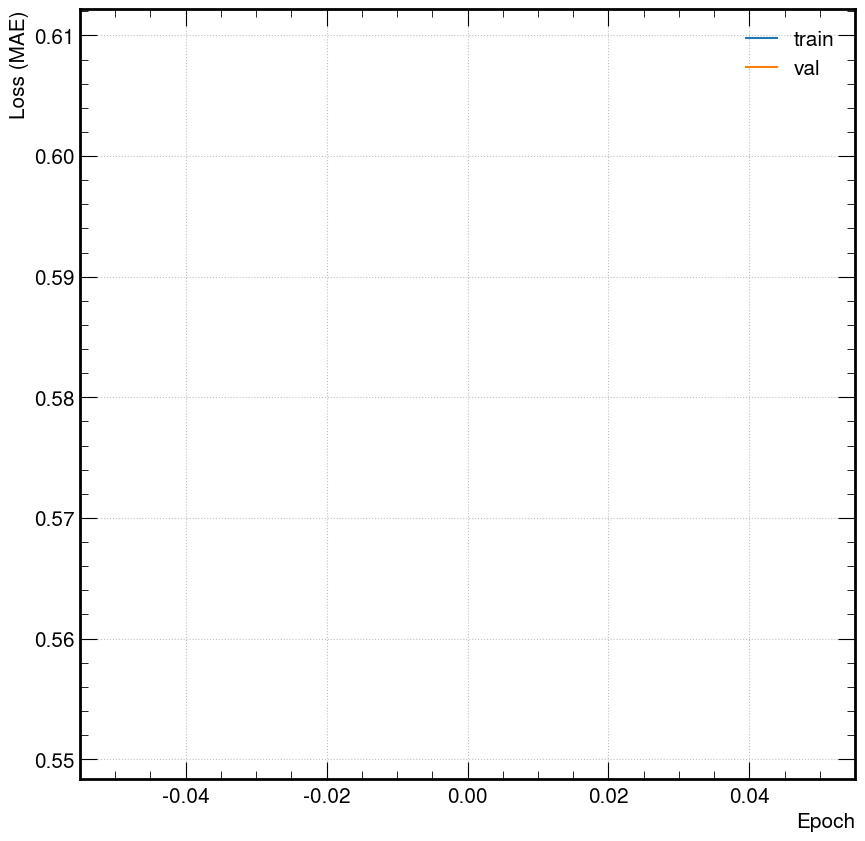

In [ ]:
npz_unpacked_loss = np.load(path_to_result + "/losses.npz")

train_loss = npz_unpacked_loss['training']
val_loss = npz_unpacked_loss['validation']

val_mean_loss=np.mean(val_loss, axis=1)
train_mean_loss=np.mean(train_loss, axis=1)

plt.plot(train_mean_loss,label='train')

plt.plot(val_mean_loss, label='val')
plt.xlabel("Epoch", fontsize=15)
plt.ylabel("Loss (MAE)", fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=15)
plt.grid()

In [11]:
# Returns a sorted array of unique target energies
energy_bins = np.unique(np.round(targets_energy).astype(int))
print(energy_bins)

[  1   2   4   5   8  12  17  25  35  51  73 104 150]


In [12]:
eta_bins = [(3.2, 3.4), (3.4,3.6), (3.6,3.8),(3.8, 4)]
truth_eta = -1*np.log(np.tan(targets_theta/2))

/tmp/ipykernel_1543217/2814570774.py:2: RuntimeWarning: invalid value encountered in log
  truth_eta = -1*np.log(np.tan(targets_theta/2))


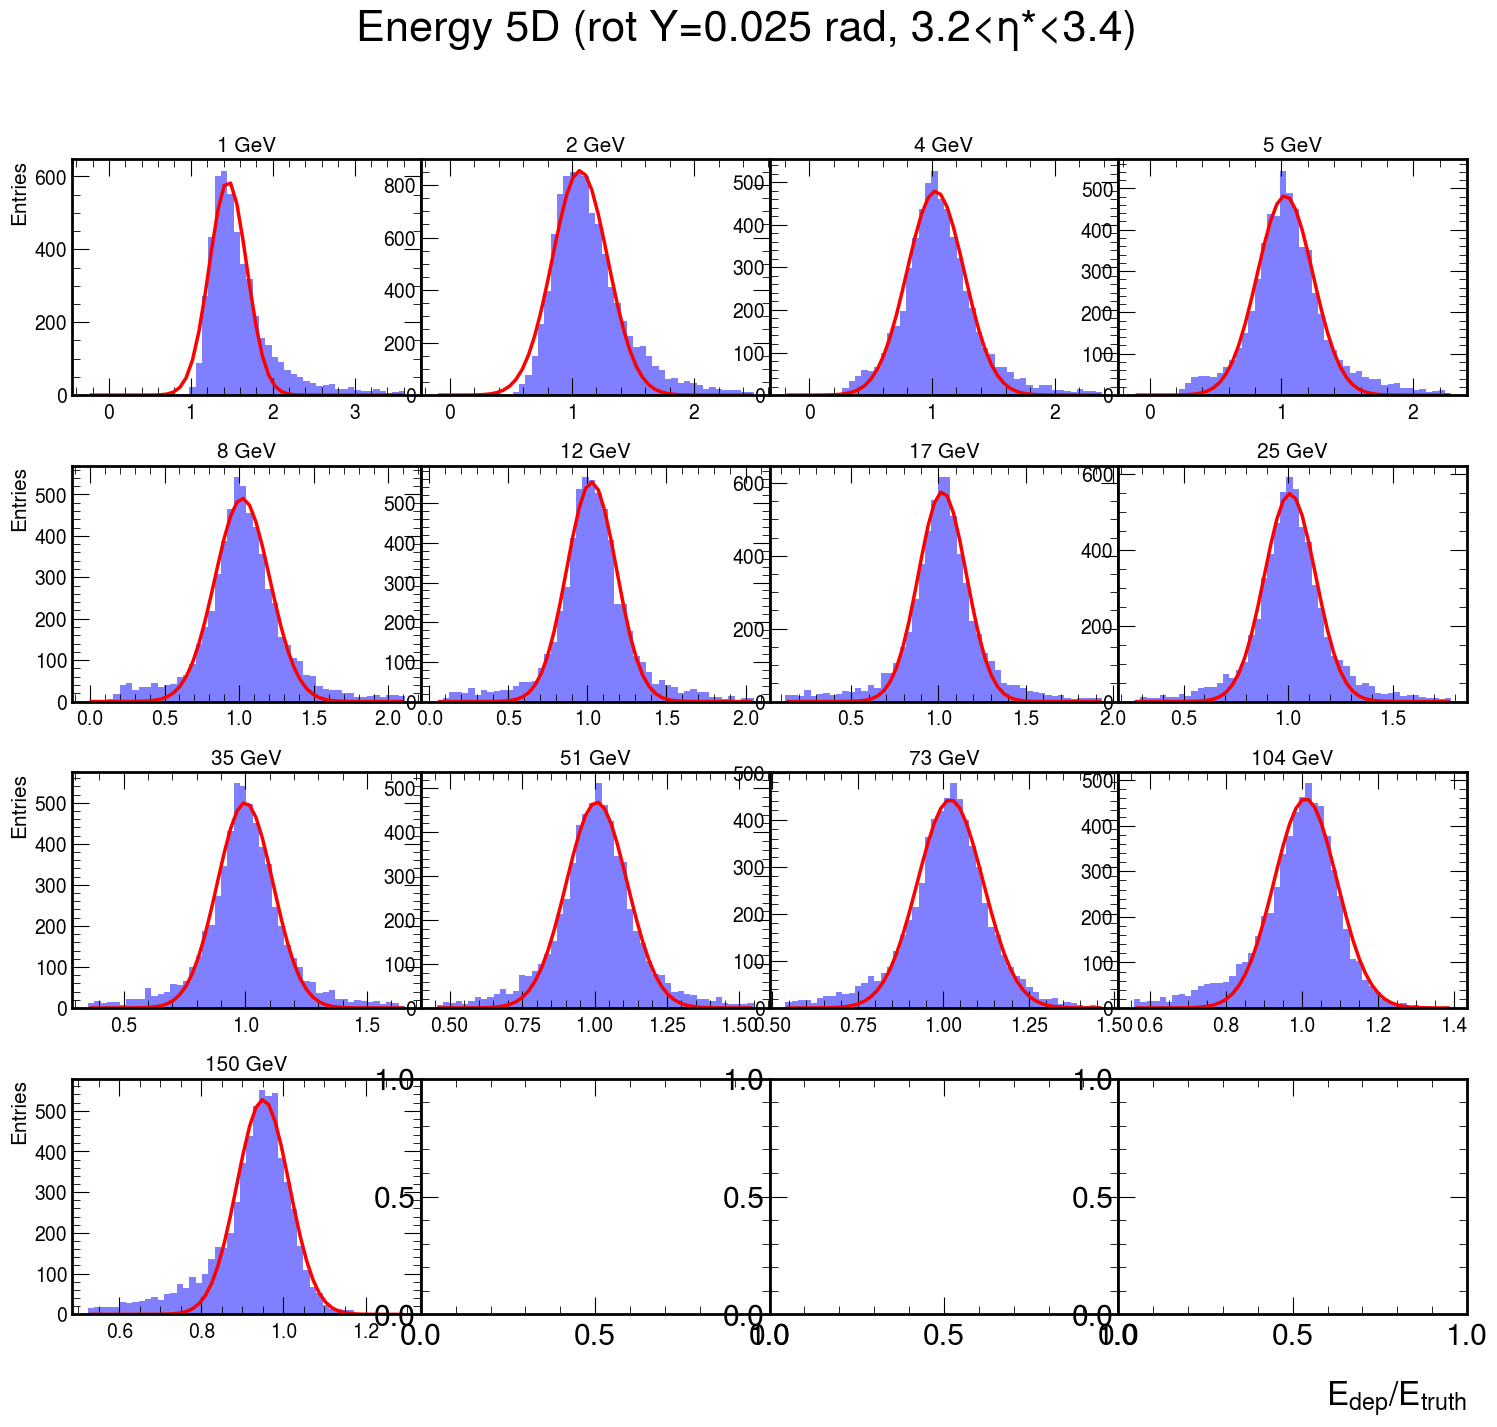

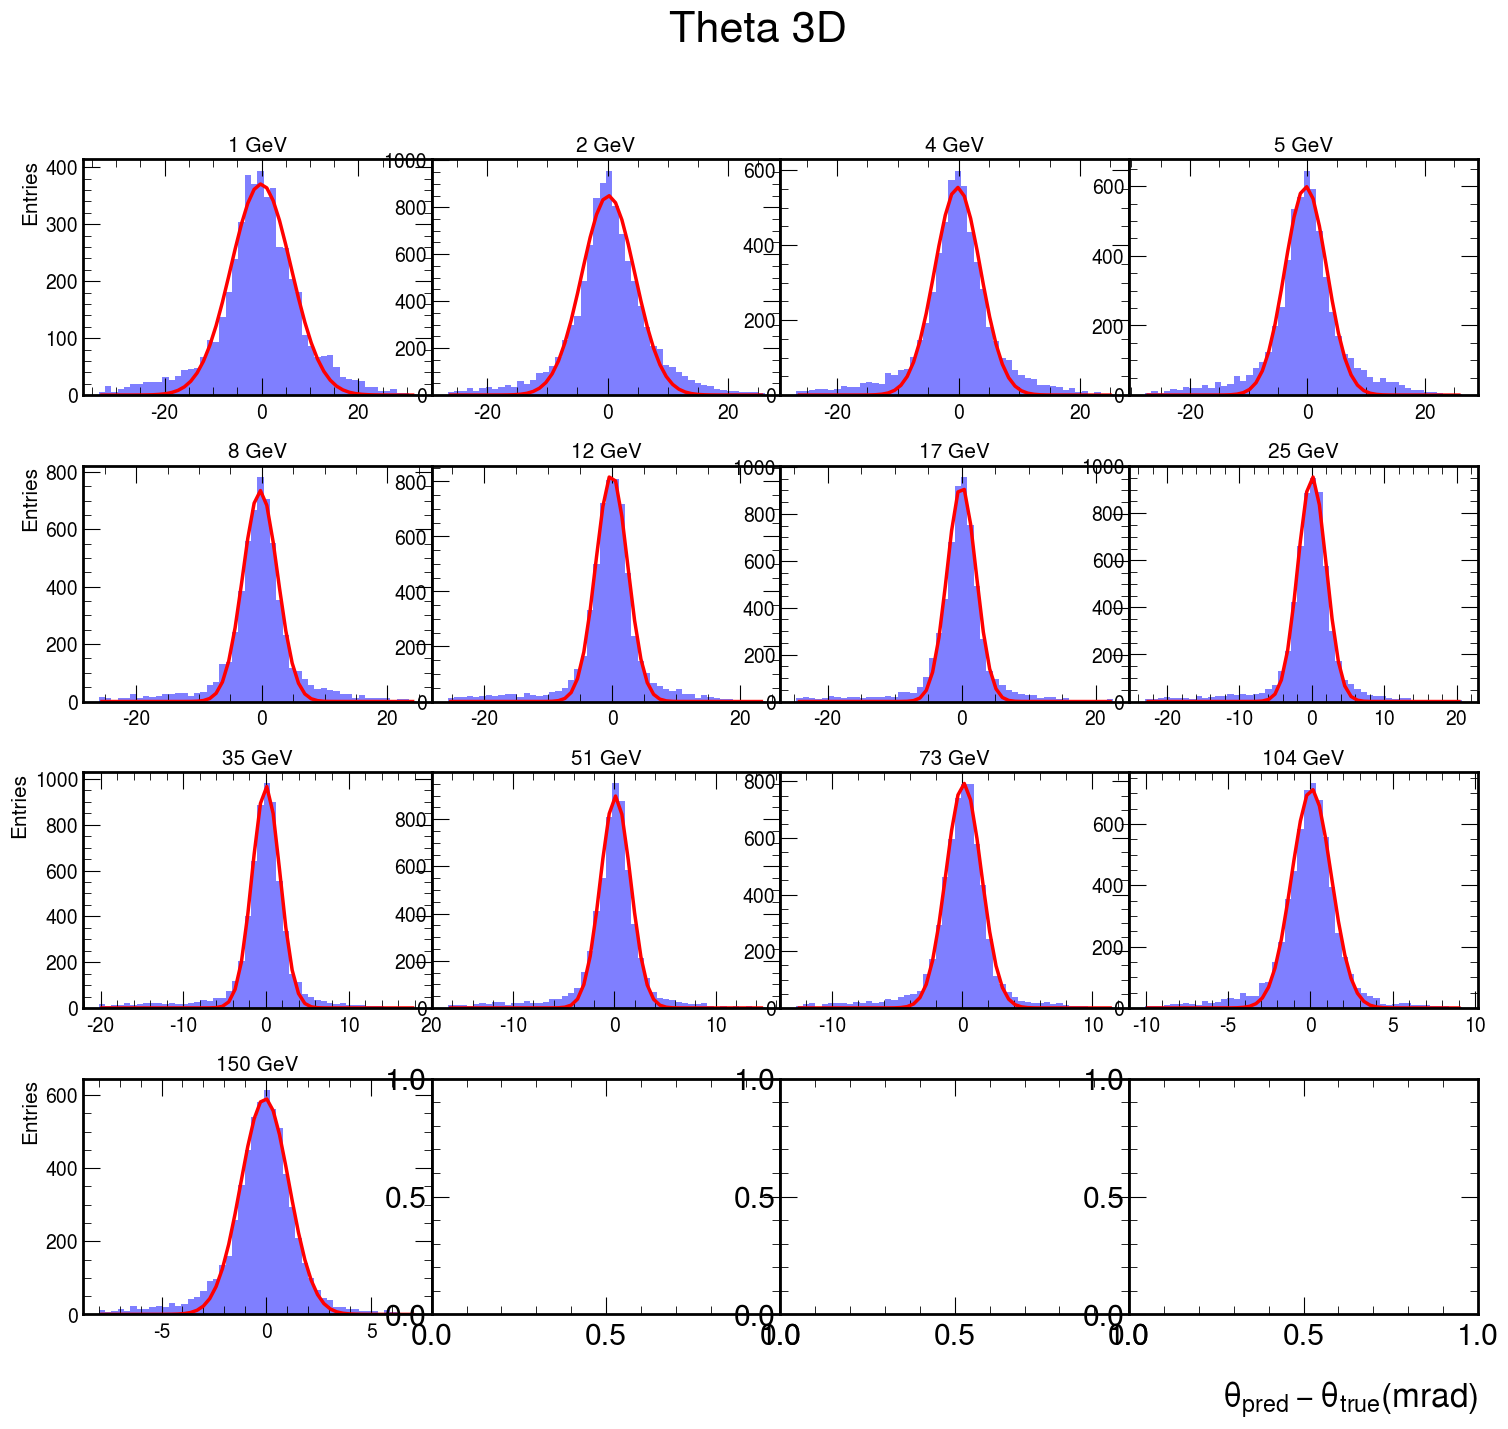

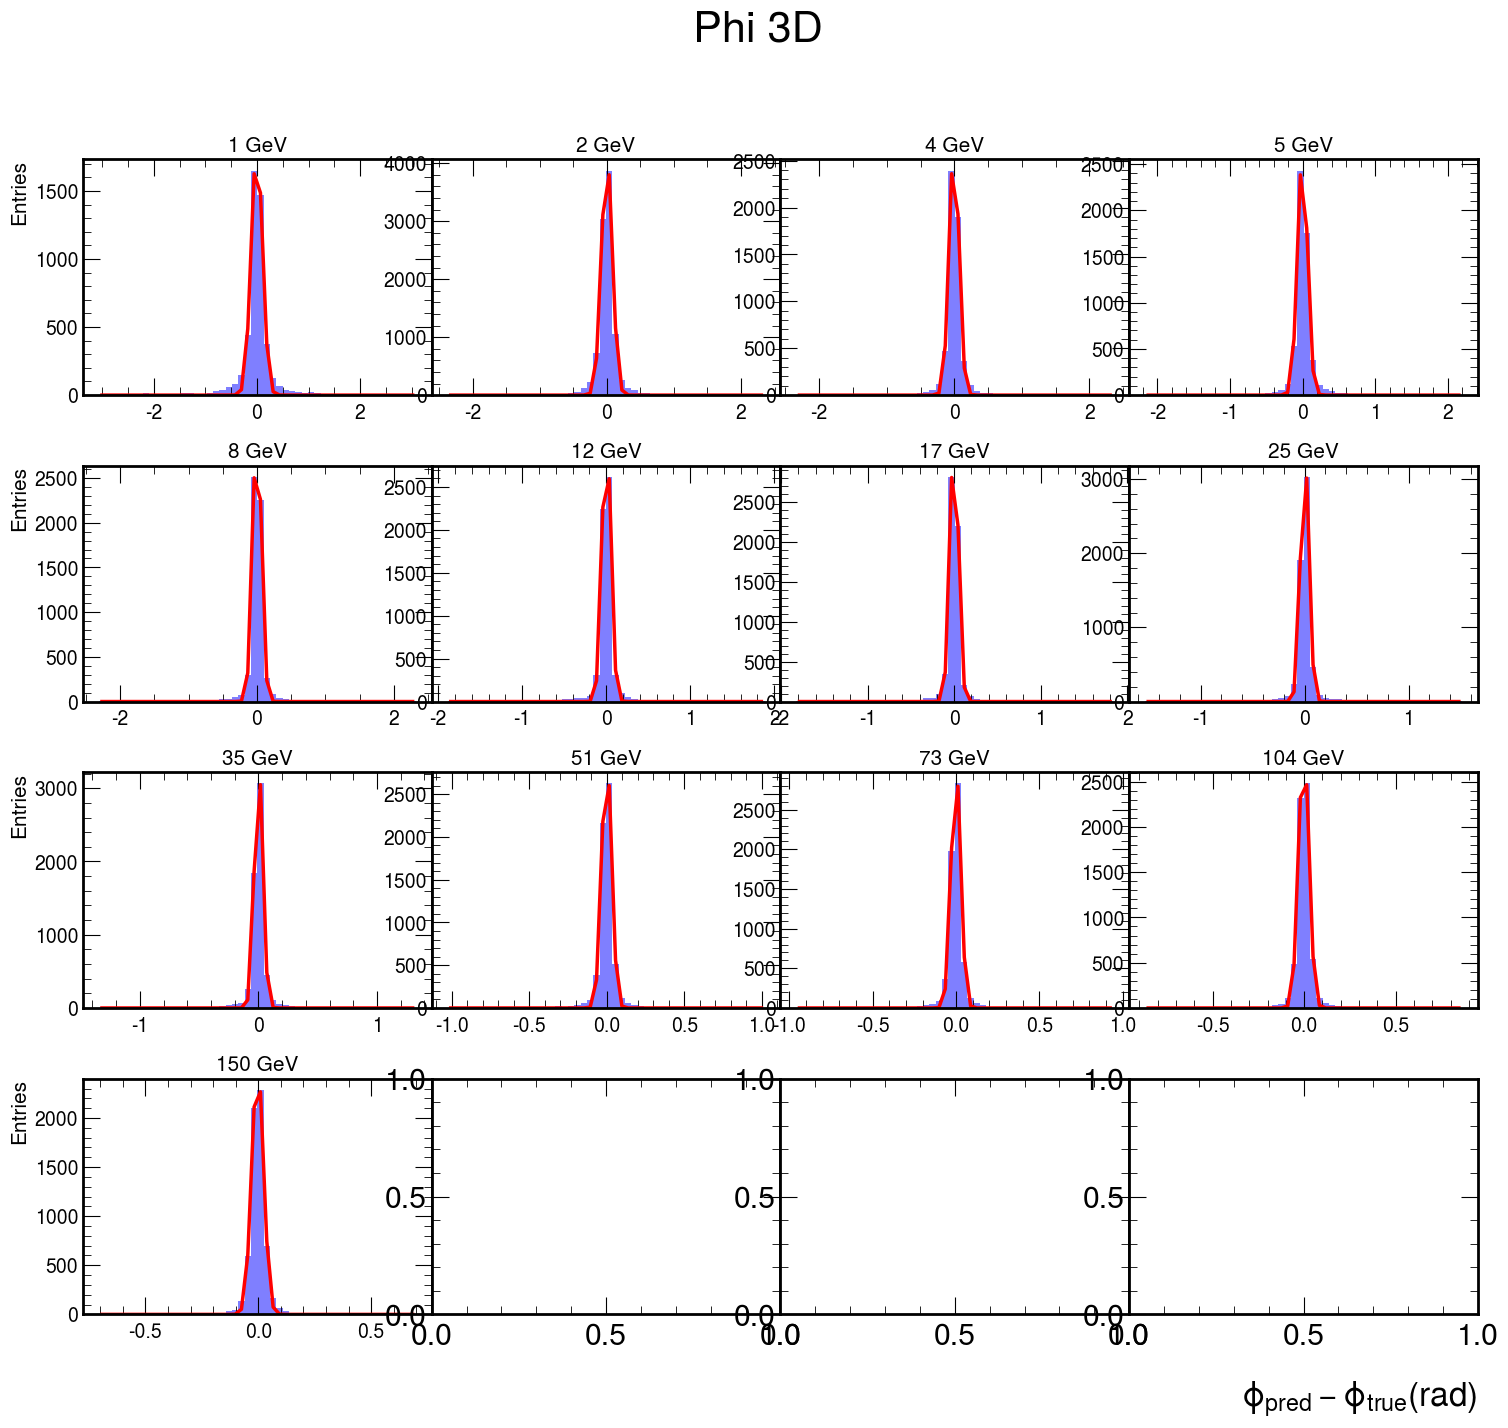

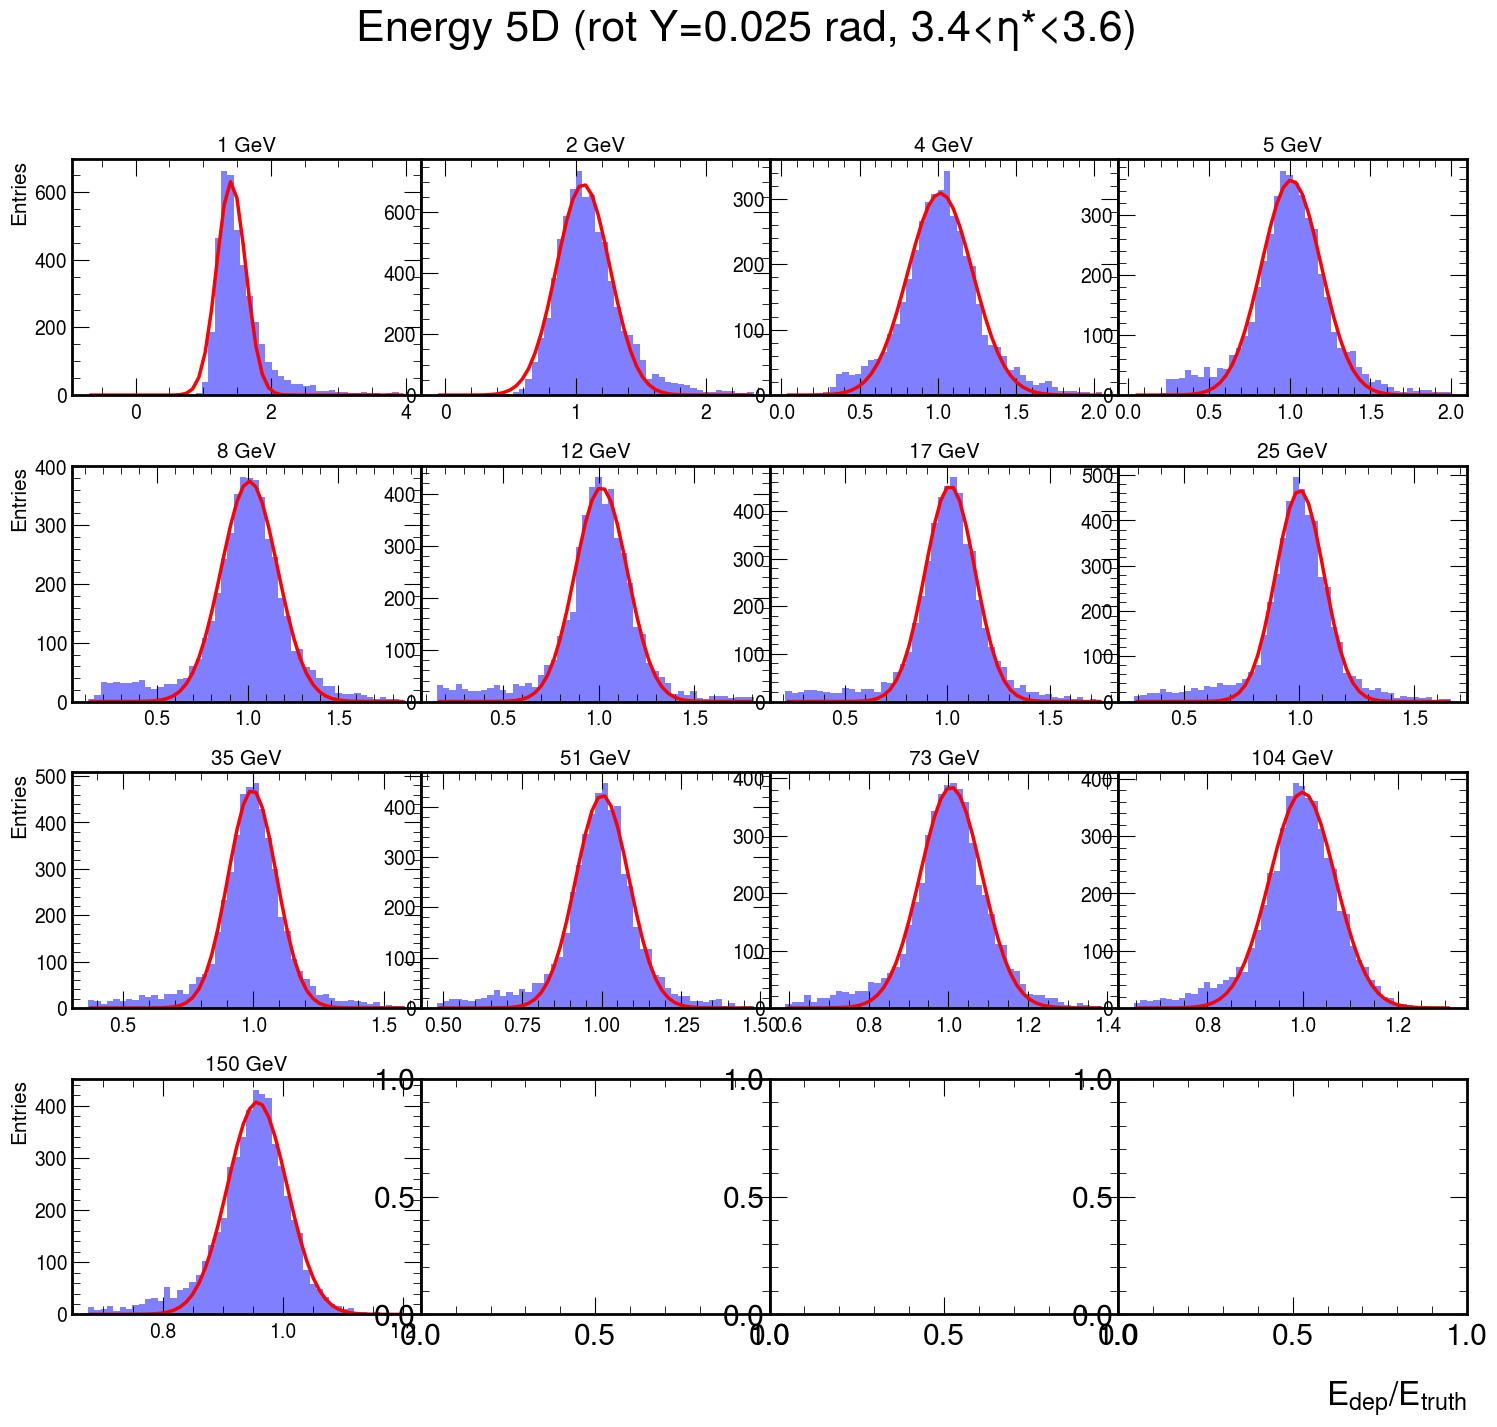

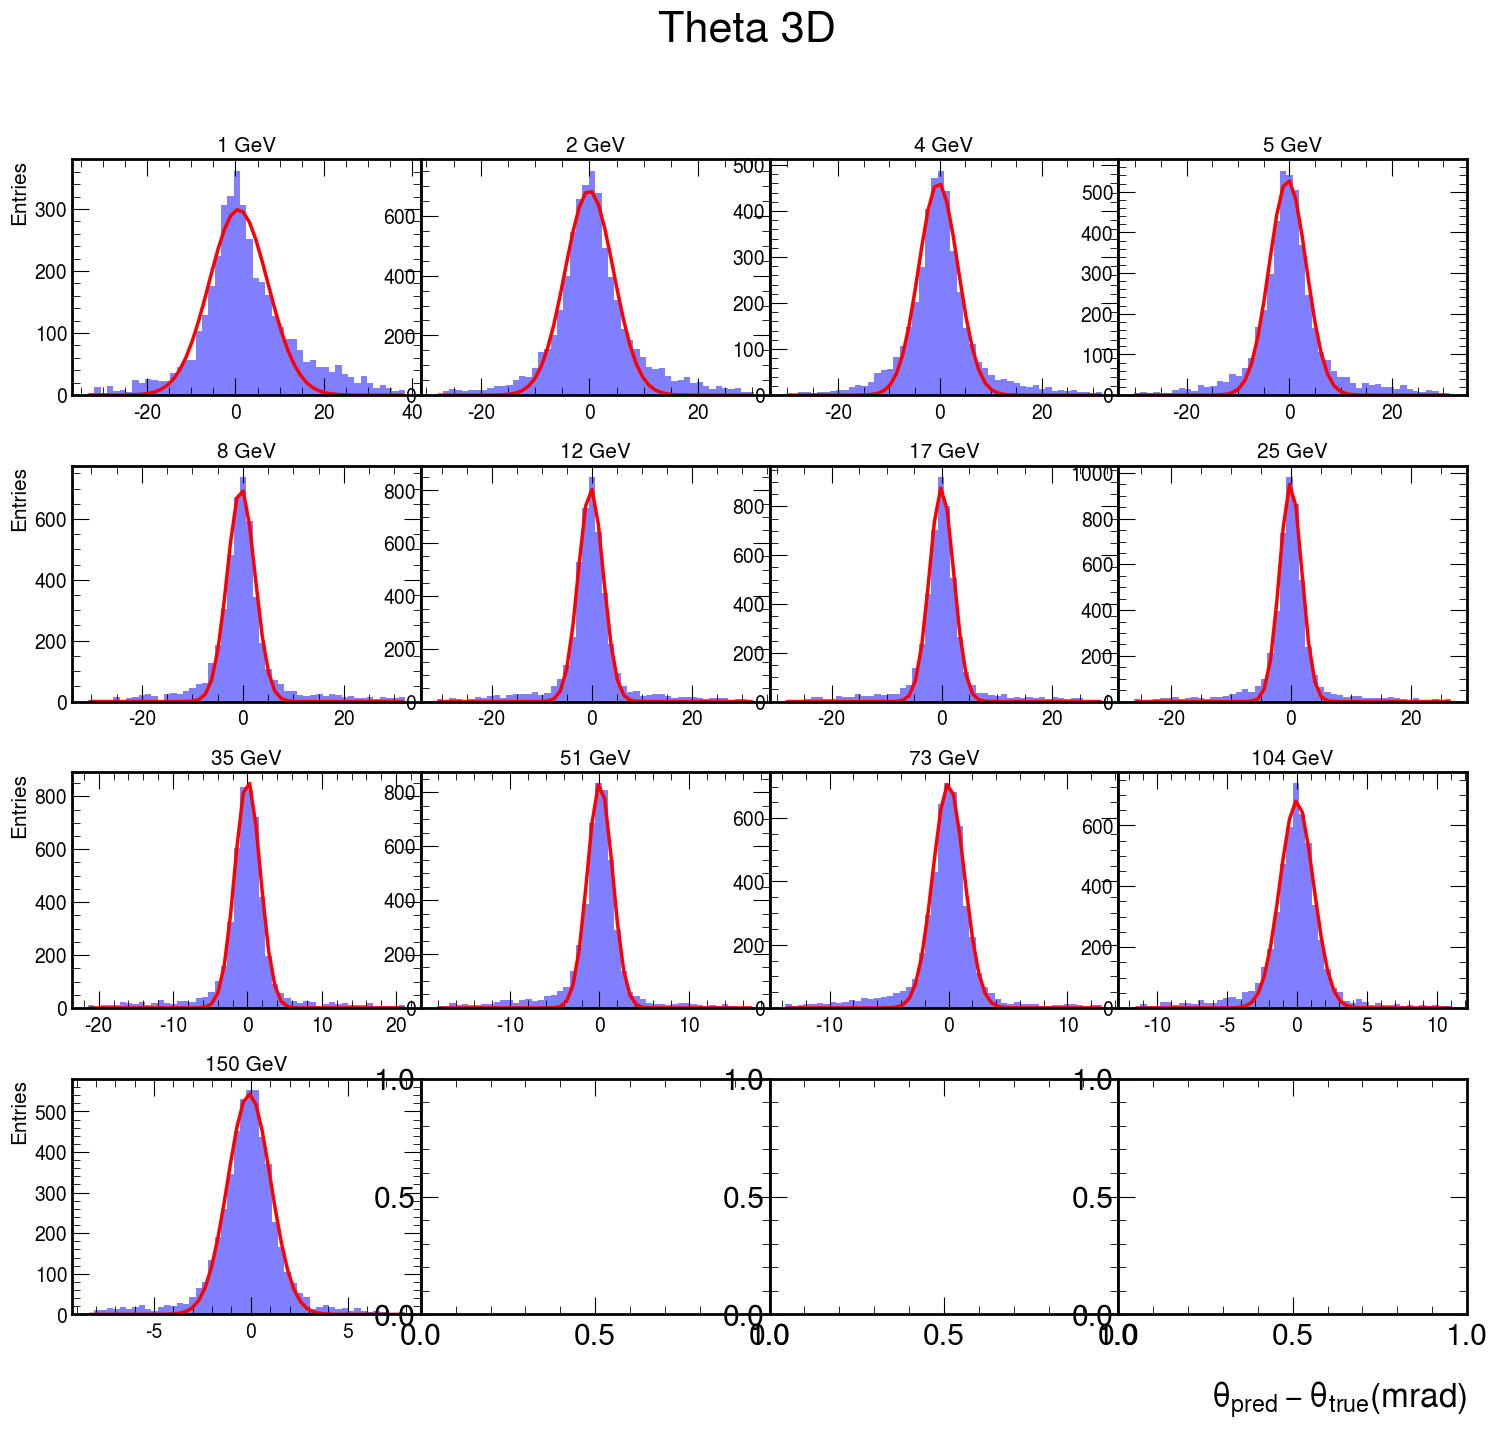

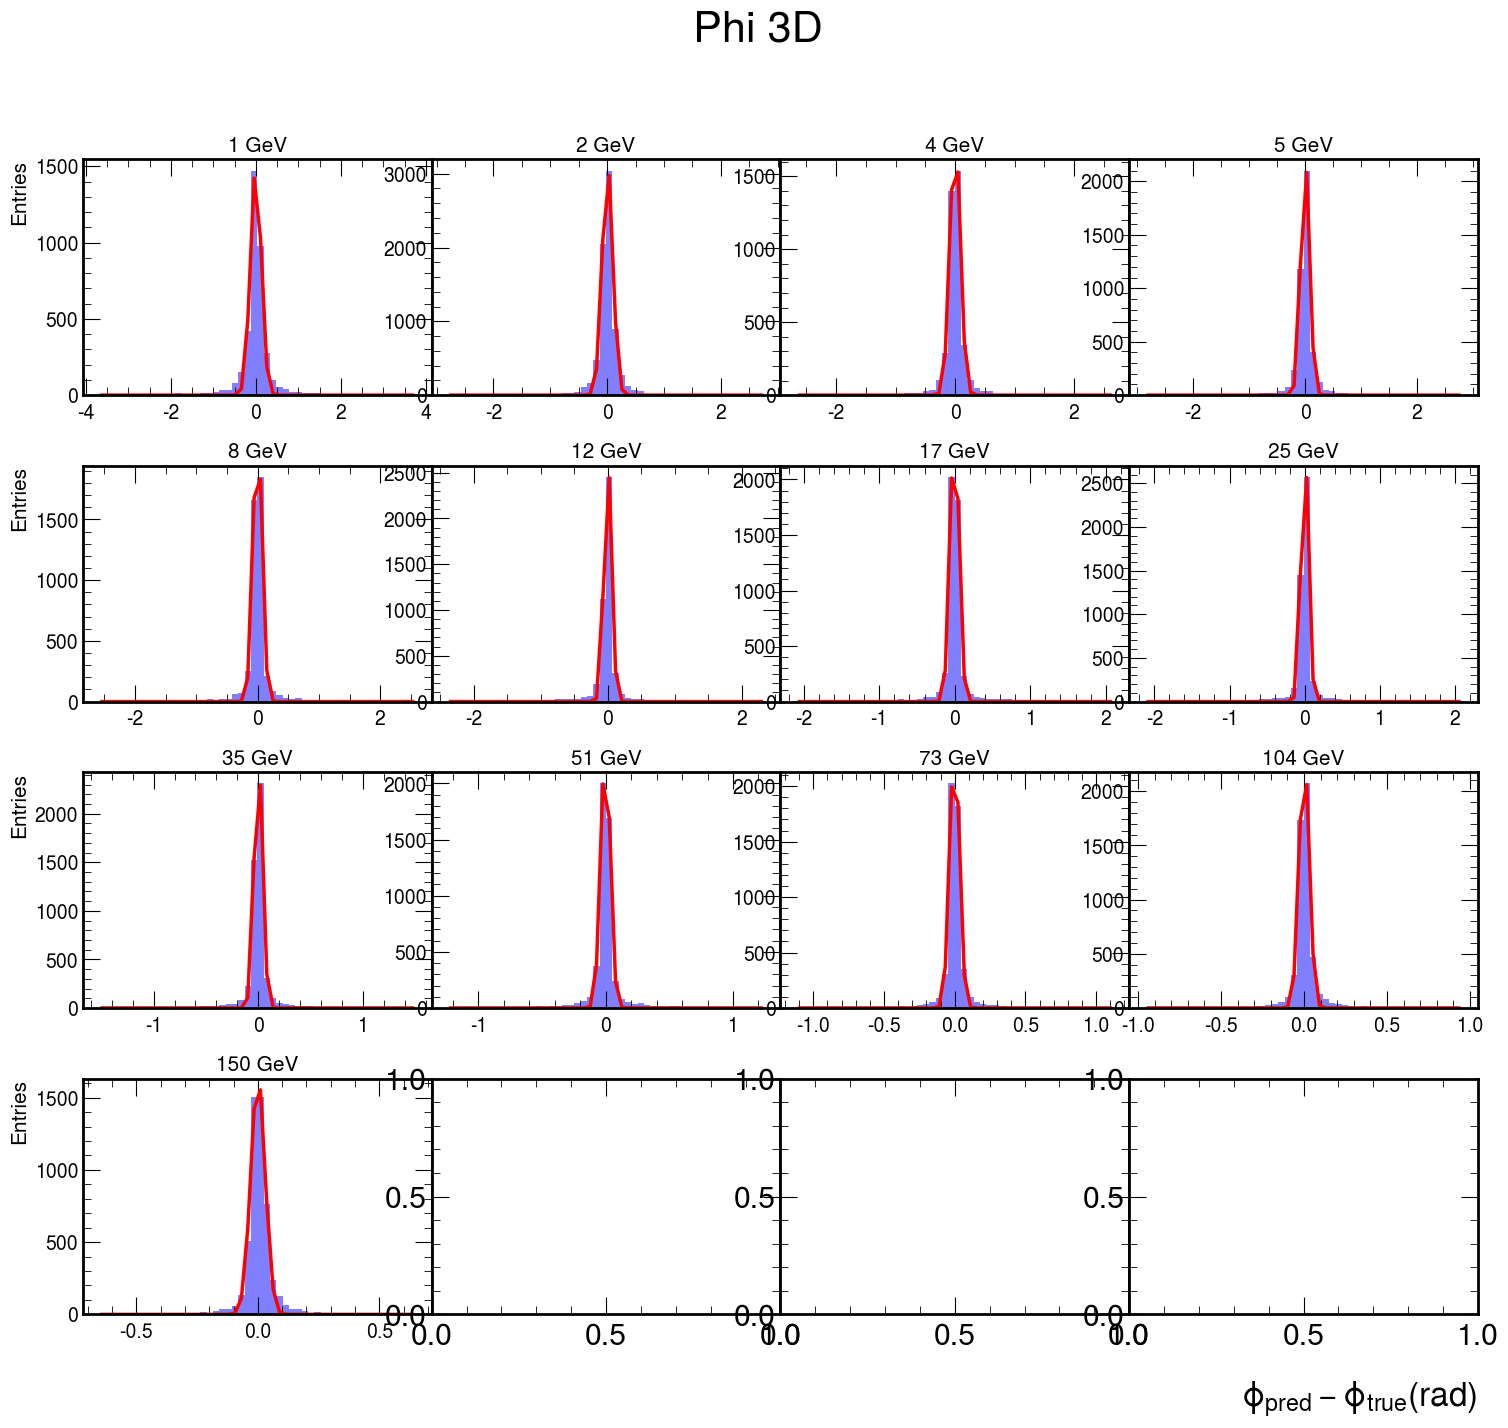

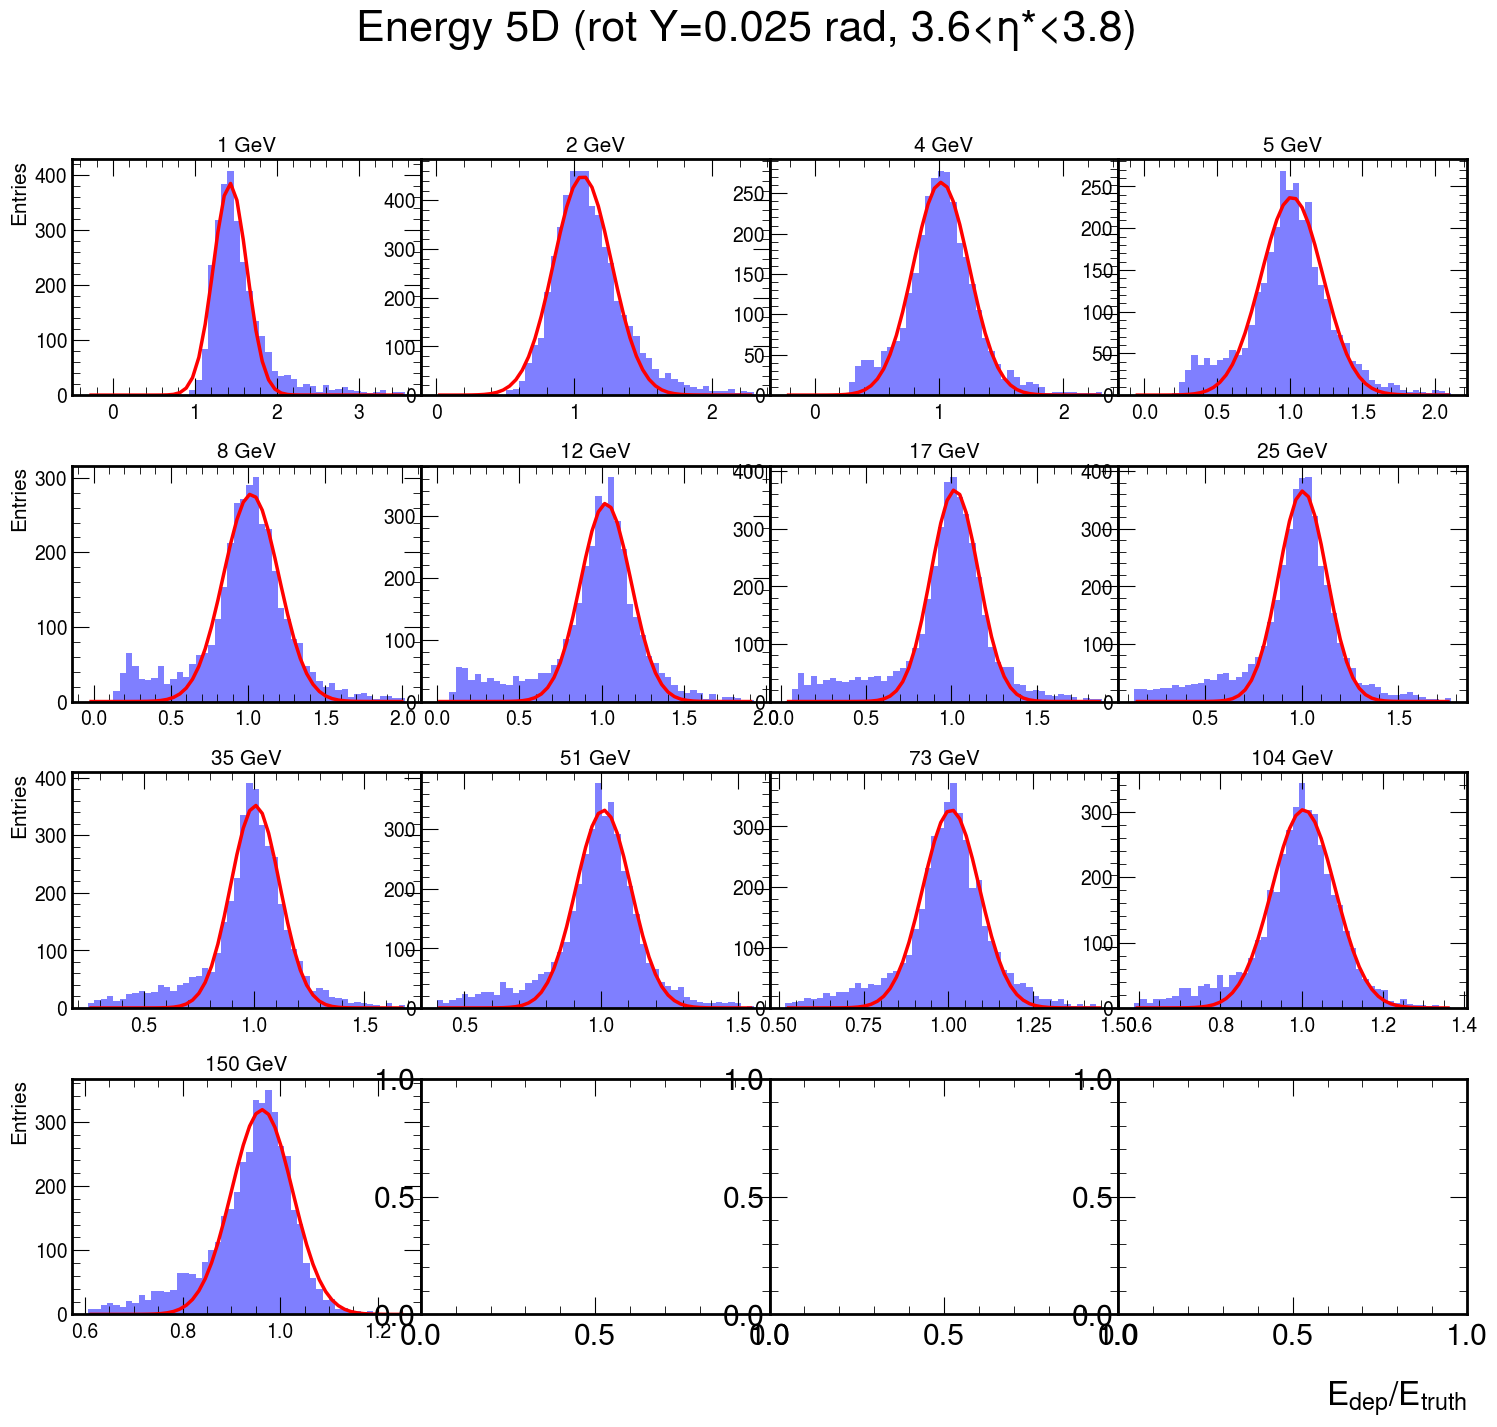

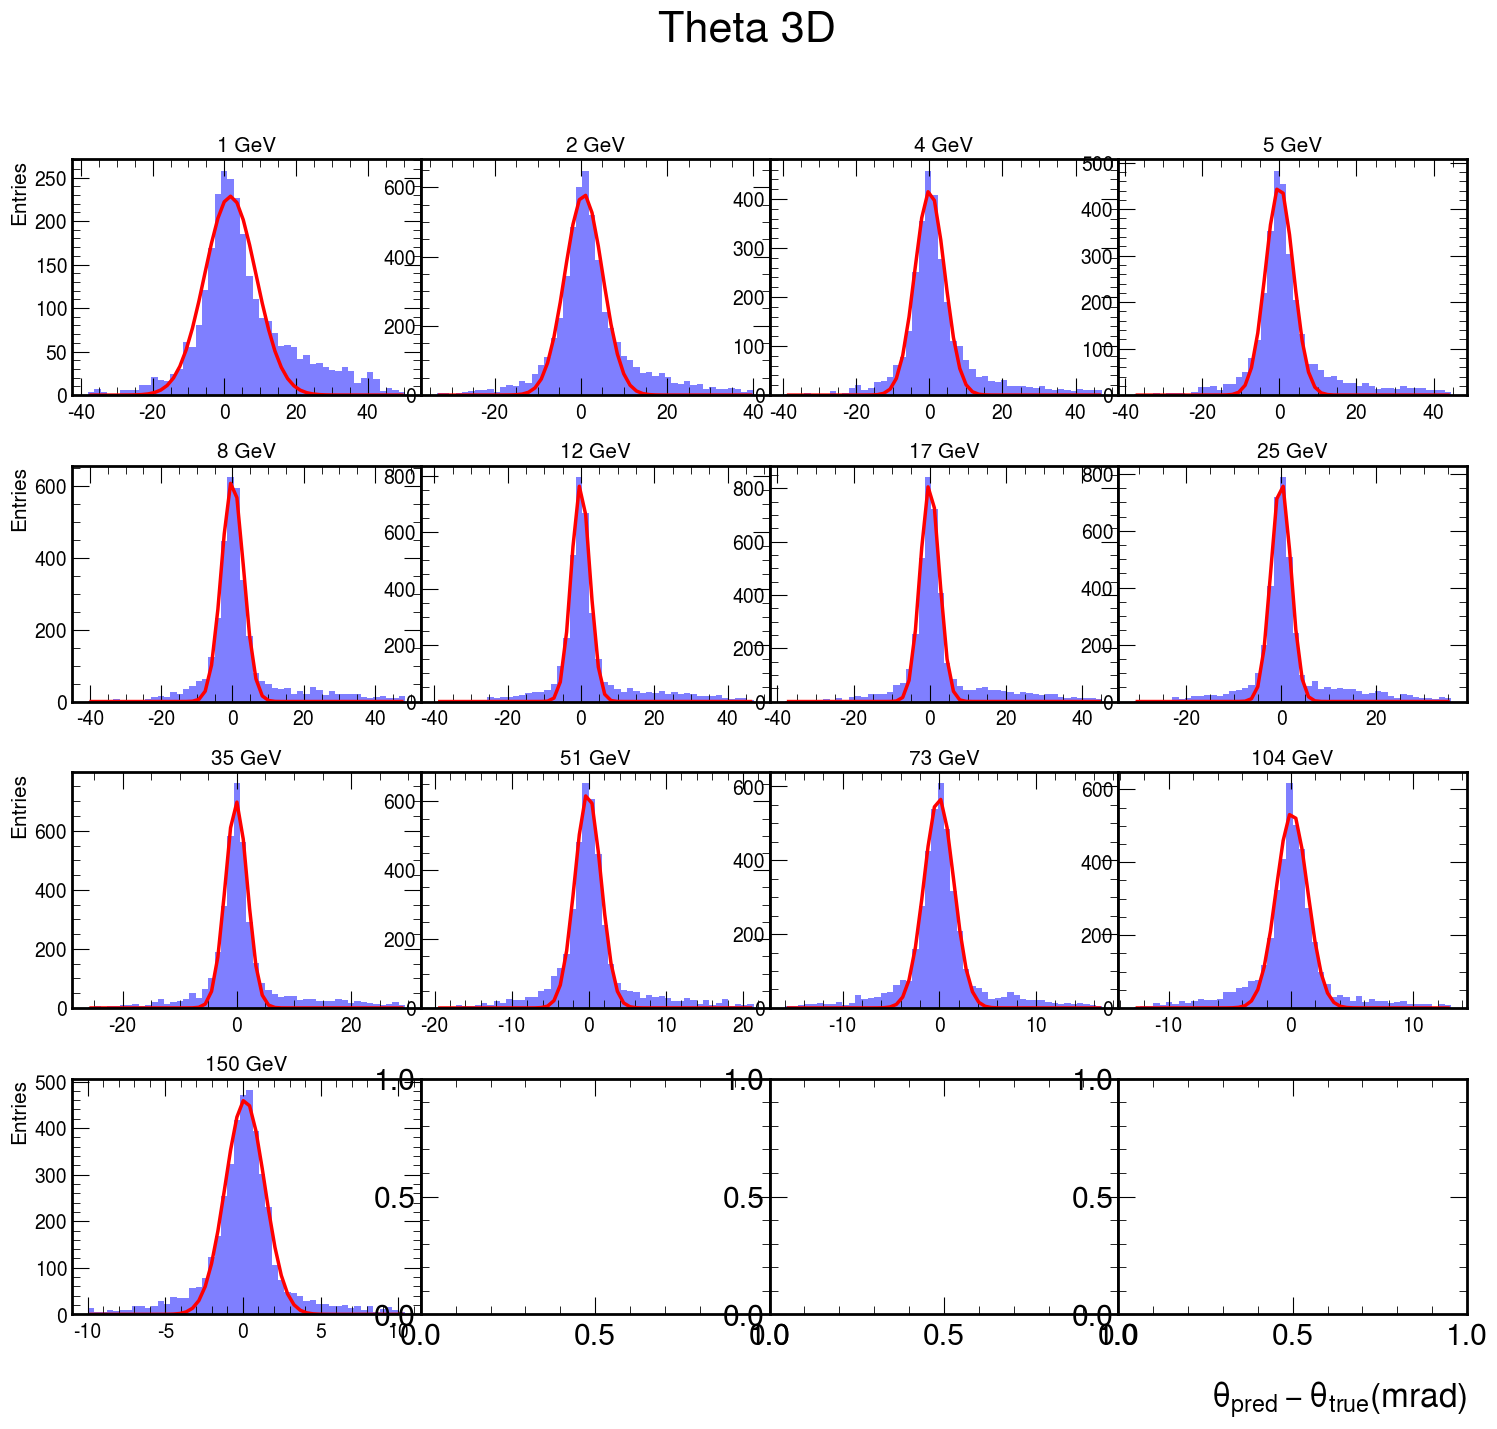

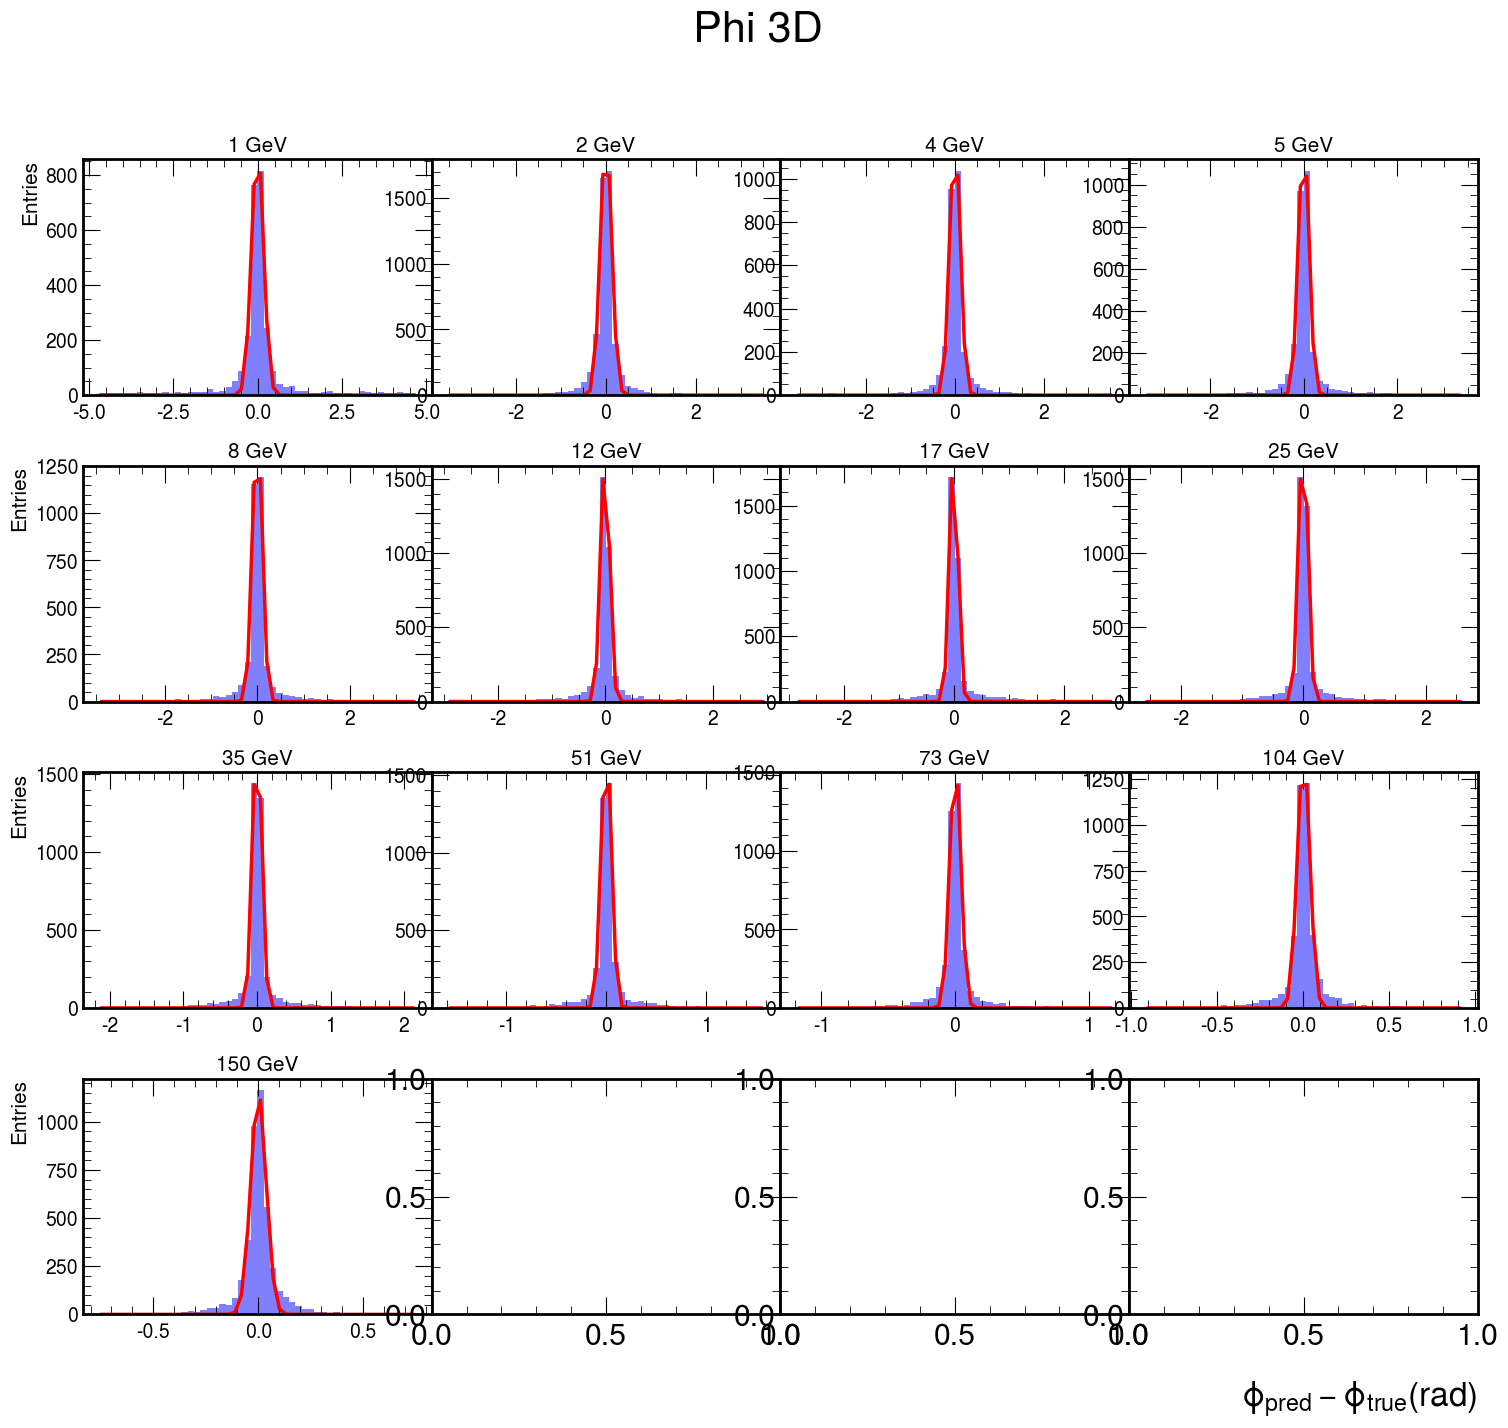

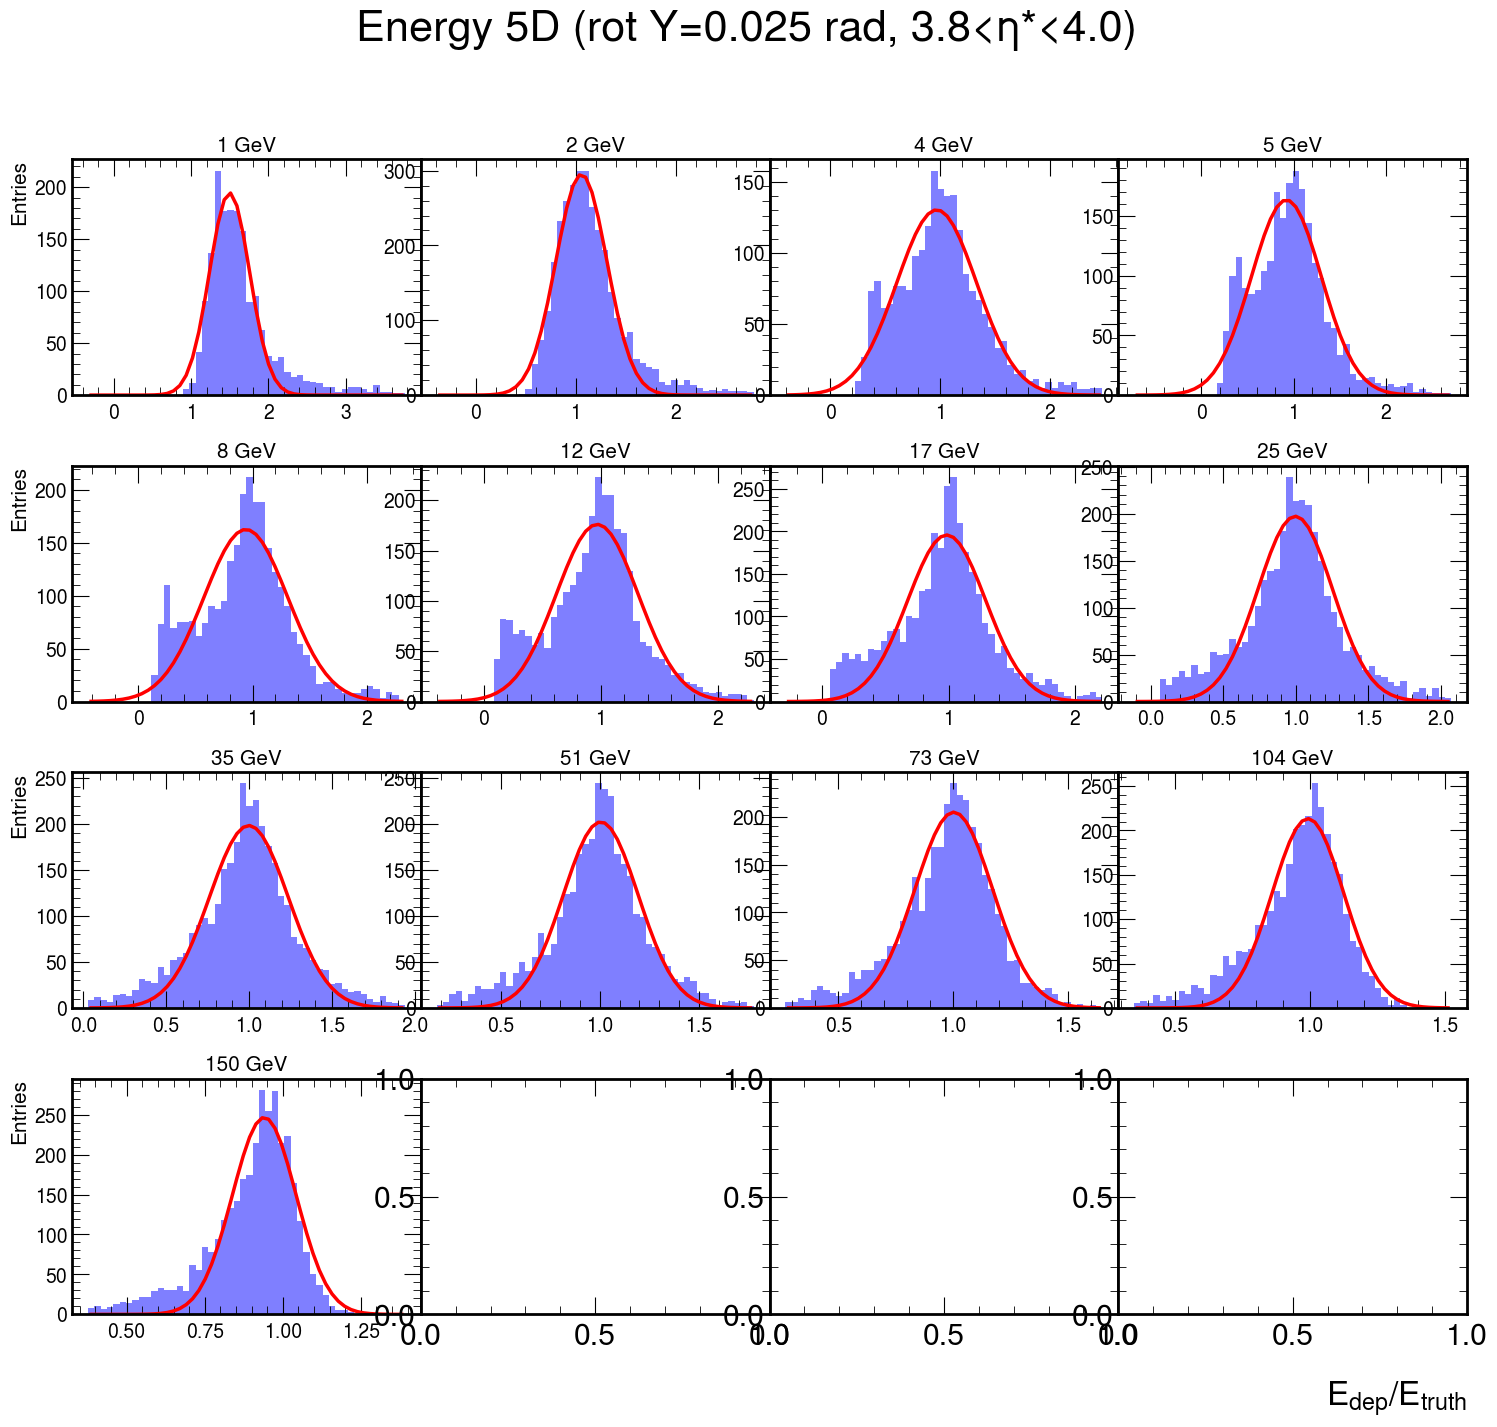

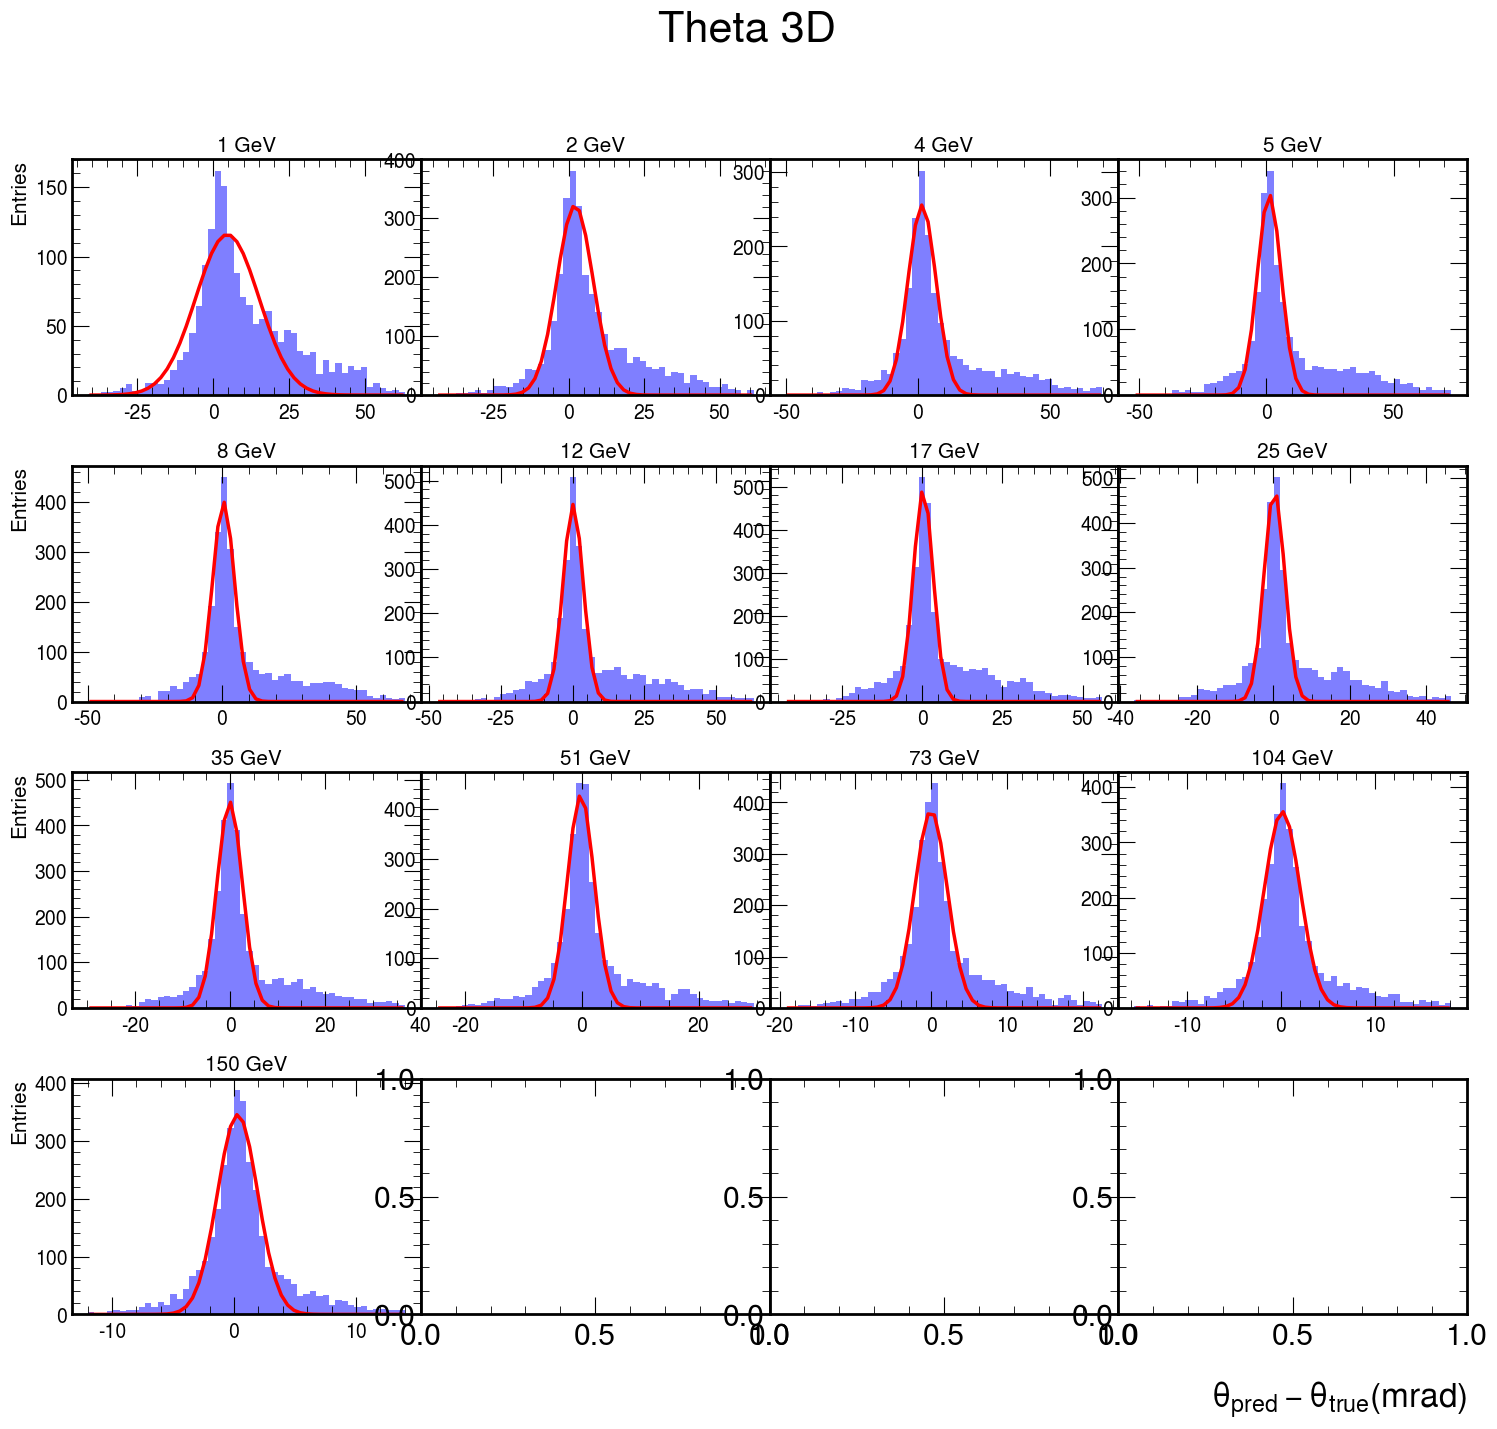

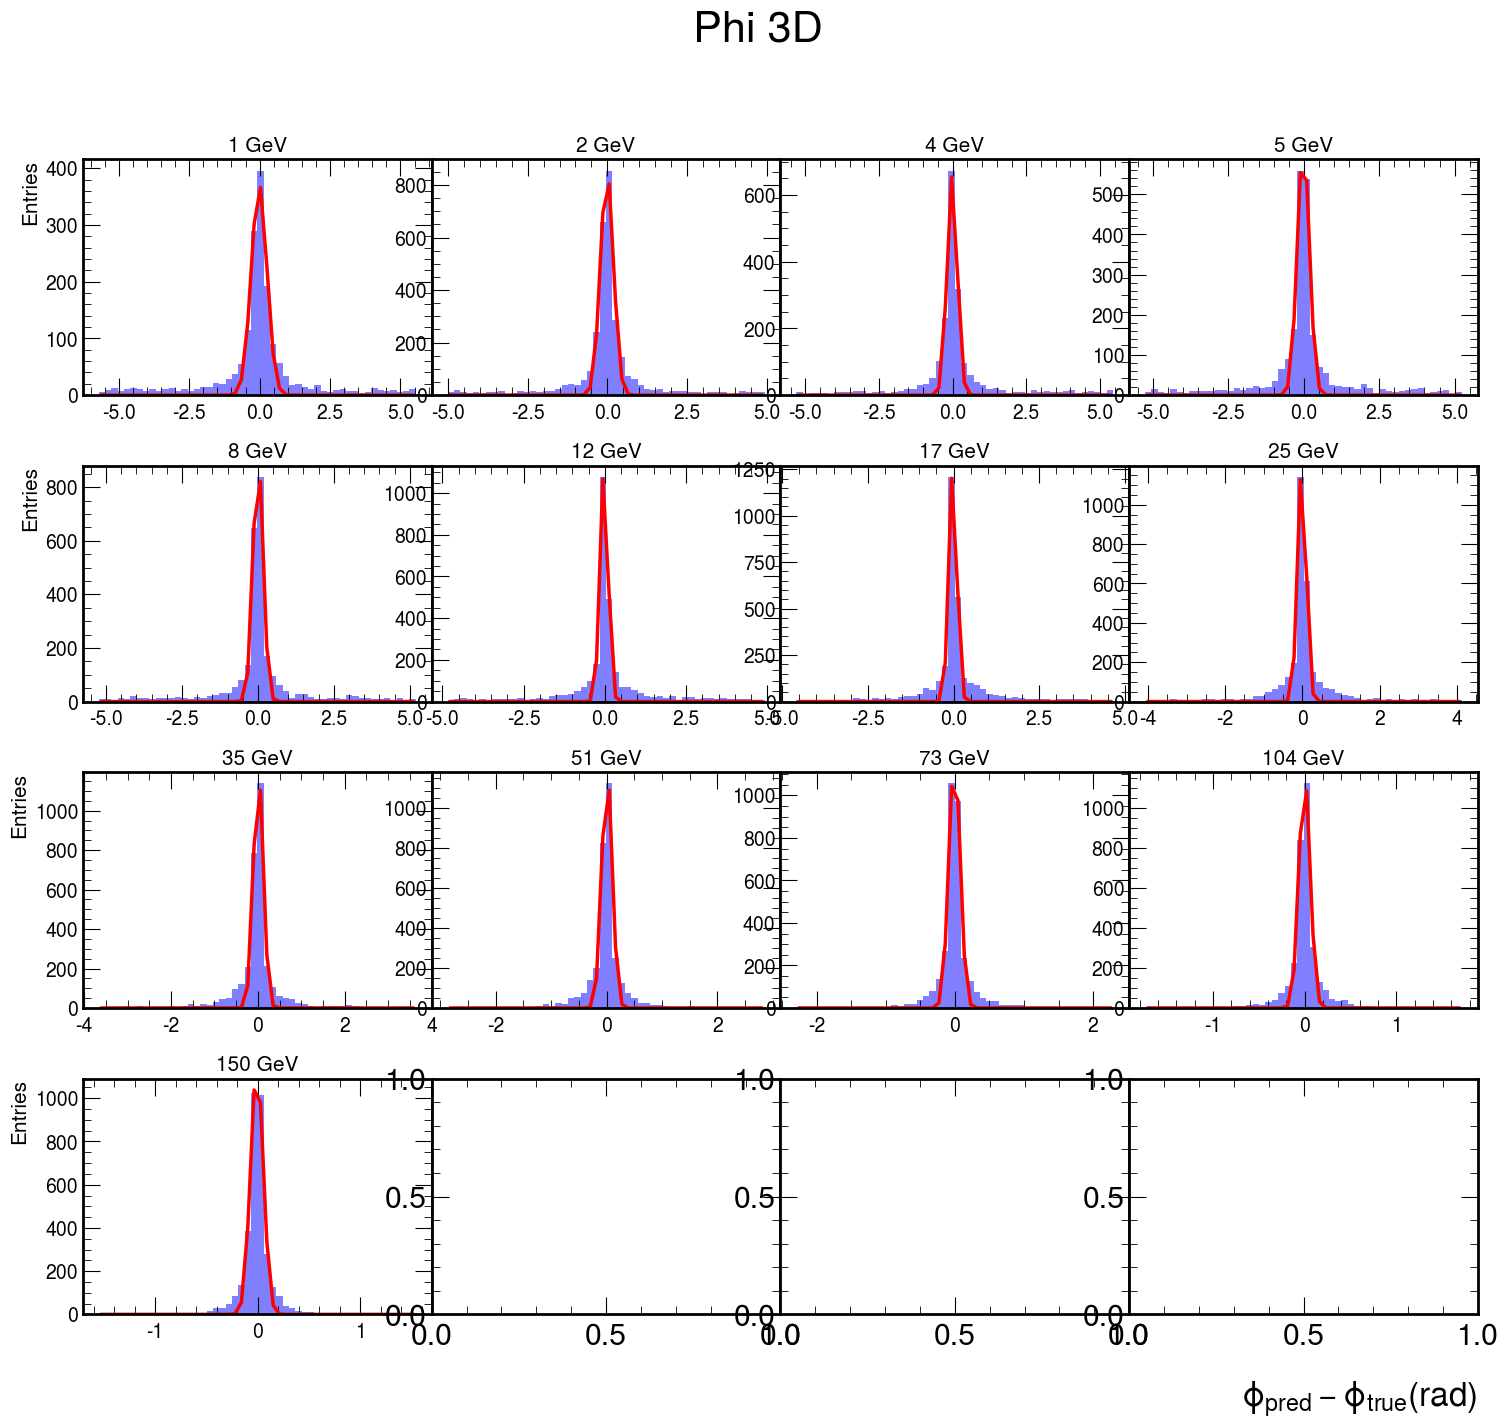

In [13]:
if not False:
    # build rotated truth eta with SAME indexing as your ML arrays
    if output_dim == '3D':
        truth_eta_rot = rotated_eta_from_theta_phi(targets_theta, targets_phi, angle_rad=0.025)
    elif output_dim == '2D':
        raise ValueError("Need phi to rotate around Y. Run a 3D target or provide phi.")
    else:
        raise ValueError("Rotation requires angular targets.")

    eta_bins = [(3.2, 3.4), (3.4, 3.6), (3.6, 3.8), (3.8, 4.0)]
    eta_truth_energies, eta_energy_resolutions, eta_energy_scales = [], [], []
    eta_theta_resolutions, eta_phi_resolutions = [], []
    for eta_range in eta_bins:
        eta_mask = (truth_eta_rot >= eta_range[0]) & (truth_eta_rot < eta_range[1])

        truth_energies, energy_resolutions, energy_scales, energy_leakage = get_resolutions(
            predictions_energy[eta_mask],
            targets_energy[eta_mask],
            energy_bins,
            nbins=50,
            data_name="energy",
            divide_by_genE=True,
            title=f"Energy 5D (rot Y=0.025 rad, {eta_range[0]}<η*<{eta_range[1]})"
        )

        eta_truth_energies.append(truth_energies)
        eta_energy_resolutions.append(energy_resolutions)
        eta_energy_scales.append(energy_scales)
        
        theta_predicted_truth_difference = predictions_theta[eta_mask] - targets_theta[eta_mask]
        _, theta_resolutions, _, _ = get_resolutions(theta_predicted_truth_difference,
                                                     targets_energy[eta_mask],
                                                     energy_bins,
                                                     nbins = 50,
                                                     data_name = "theta",
                                                     title="Theta 3D")
        
        eta_theta_resolutions.append(theta_resolutions)
        
        phi_predicted_truth_difference = predictions_phi[eta_mask] - targets_phi[eta_mask]
        _, phi_resolutions, _, _ = get_resolutions(phi_predicted_truth_difference,
                                                   targets_energy[eta_mask],
                                                   energy_bins,
                                                   nbins = 50,
                                                   data_name = "phi",
                                                   title="Phi 3D")
        
        eta_phi_resolutions.append(phi_resolutions)
        
else:
    eta_truth_energies, eta_energy_resolutions, eta_energy_scales = [], [], []
    eta_theta_resolutions, eta_phi_resolutions = [], []
    for eta_range in eta_bins:
        eta_mask = (truth_eta>=eta_range[0]) & (truth_eta<eta_range[1])
        truth_energies, energy_resolutions, energy_scales, energy_leakage = get_resolutions(predictions_energy[eta_mask],
                                                                                            targets_energy[eta_mask],
                                                                                            energy_bins,
                                                                                            nbins = 50,
                                                                                            data_name = "energy",
                                                                                            divide_by_genE = True,
                                                                                            title="Energy 3D")
        eta_truth_energies.append(truth_energies)
        eta_energy_resolutions.append(energy_resolutions)
        eta_energy_scales.append(energy_scales)
        
        theta_predicted_truth_difference = predictions_theta[eta_mask] - targets_theta[eta_mask]
        _, theta_resolutions, _, _ = get_resolutions(theta_predicted_truth_difference,
                                                     targets_energy[eta_mask],
                                                     energy_bins,
                                                     nbins = 50,
                                                     data_name = "theta",
                                                     title="Theta 3D")
        
        eta_theta_resolutions.append(theta_resolutions)
        
        phi_predicted_truth_difference = predictions_phi[eta_mask] - targets_phi[eta_mask]
        _, phi_resolutions, _, _ = get_resolutions(phi_predicted_truth_difference,
                                                   targets_energy[eta_mask],
                                                   energy_bins,
                                                   nbins = 50,
                                                   data_name = "phi",
                                                   title="Phi 3D")
        
        eta_phi_resolutions.append(phi_resolutions)

In [14]:
def resolution_eqn(x, a, c):
    return np.sqrt((a/np.sqrt(x))**2 +c*c)

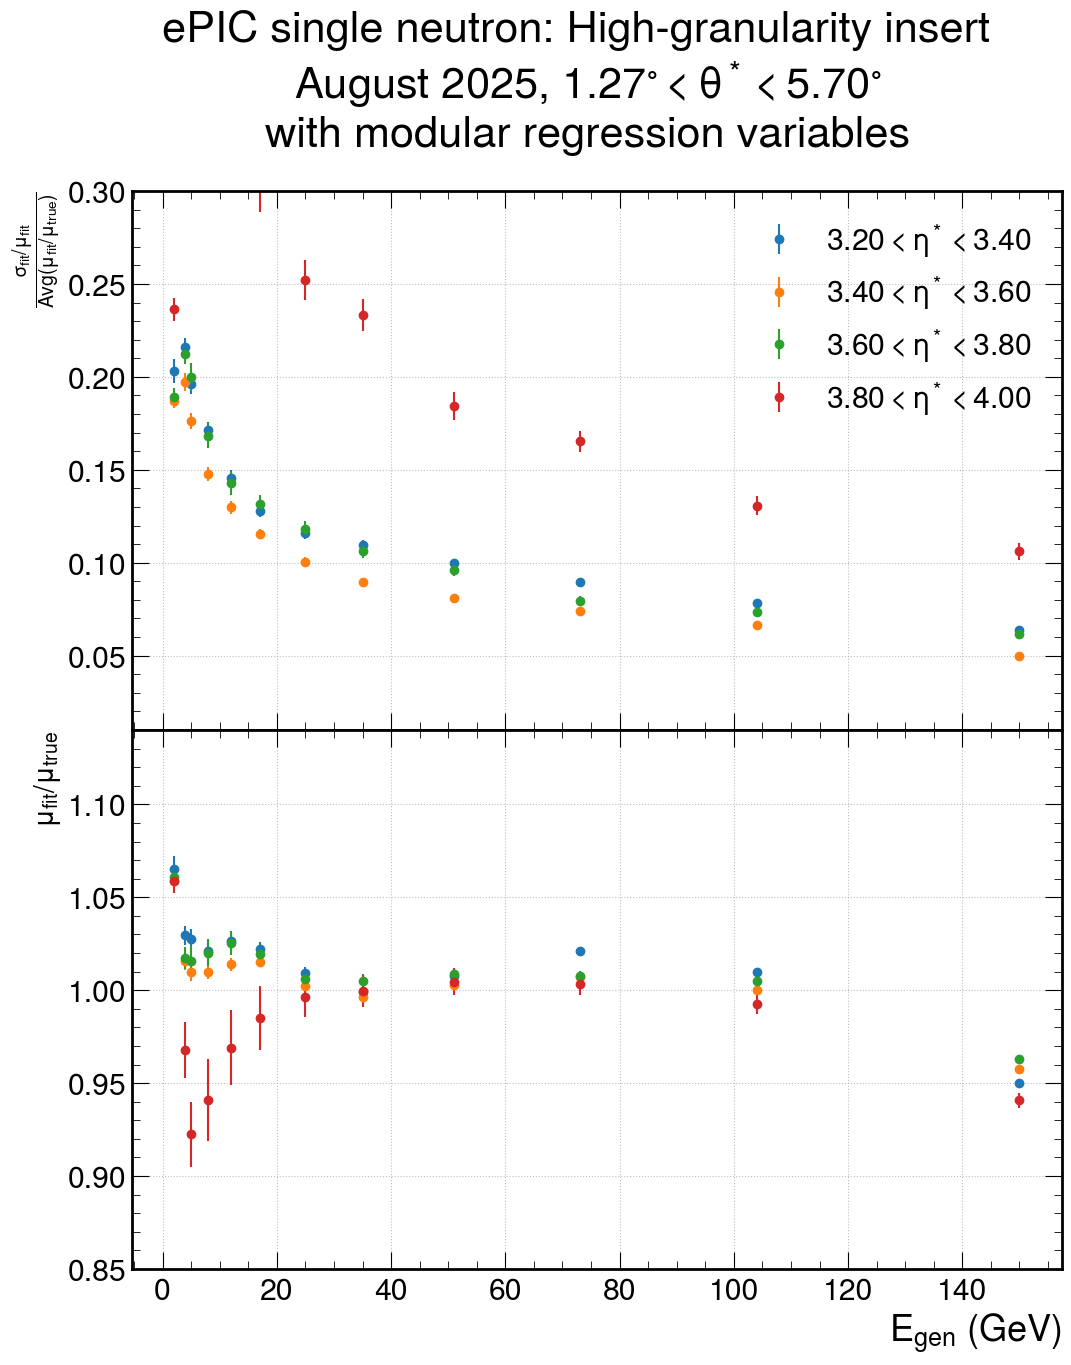

In [18]:
fig = plt.figure(figsize=(12,14))
fig.set_facecolor('w')
gs = fig.add_gridspec(2, hspace=0)
axs = gs.subplots(sharex=True, sharey=False)

lower_energy_lim = 2
for i, eta_range in enumerate(eta_bins):
    truth_energy = eta_truth_energies[i]
    energy_mask = truth_energy>=lower_energy_lim
    energy_resolution = eta_energy_resolutions[i][0]
    energy_resolution_error = eta_energy_resolutions[i][1]
    energy_scale = eta_energy_scales[i][0]
    energy_scale_error = eta_energy_scales[i][1]
    axs[0].errorbar(truth_energy[energy_mask],
                    np.asarray(energy_resolution)[energy_mask],
                    yerr = np.asarray(energy_resolution_error)[energy_mask],
                    marker='o',
                    linestyle='none',
                    label = f"${eta_range[0]:.2f}<\eta^*<{eta_range[1]:.2f}$")
    axs[0].set_ylabel("$\\frac{\sigma_{fit}/\mu_{fit}}{Avg (\mu_{fit}/\mu_{true})}$",  fontsize=20)
    axs[0].set_ylim(0.01, .3)
    
    axs[1].errorbar(truth_energy[energy_mask],
                    np.asarray(energy_scale)[energy_mask],
                    yerr = np.asarray(energy_scale_error)[energy_mask],
                    marker='o',
                    linestyle='none')
    axs[1].set_ylim(.85, 1.14)

axs[0].legend()
axs[1].set_ylabel("$\mu_{fit}/\mu_{true}$",  fontsize=20)
axs[1].set_xlabel("$E_{gen}$ (GeV)")
axs[0].grid()
axs[1].grid()
if granularity=="high_granularity":
    if theta_mask:
        plt.suptitle(f"ePIC single neutron: High-granularity insert \n {date}, ${theta_low:.2f}^{{\circ}}<\\theta^*<{theta_high:.2f}^{{\circ}}$\n with  ${2.3:.2f}^{{\circ}}<\\theta^*<{4.25:.2f}^{{\circ}}$ mask", y=1.01)
    else:
        plt.suptitle(f"ePIC single neutron: High-granularity insert \n {date}, ${theta_low:.2f}^{{\circ}}<\\theta^*<{theta_high:.2f}^{{\circ}}$\n with modular regression variables", y=1.01)
else:
    if theta_mask:
        plt.suptitle(f"ePIC single neutron: Low-granularity insert \n {date}, ${theta_low:.2f}^{{\circ}}<\\theta^*<{theta_high:.2f}^{{\circ}}$\n with  ${2.3:.2f}^{{\circ}}<\\theta^*<{4.25:.2f}^{{\circ}}$ mask", y=1.01)
    else:
        plt.suptitle(f"ePIC single neutron: Low-granularity insert \n {date}, ${theta_low:.2f}^{{\circ}}<\\theta^*<{theta_high:.2f}^{{\circ}}$", y=1.01)

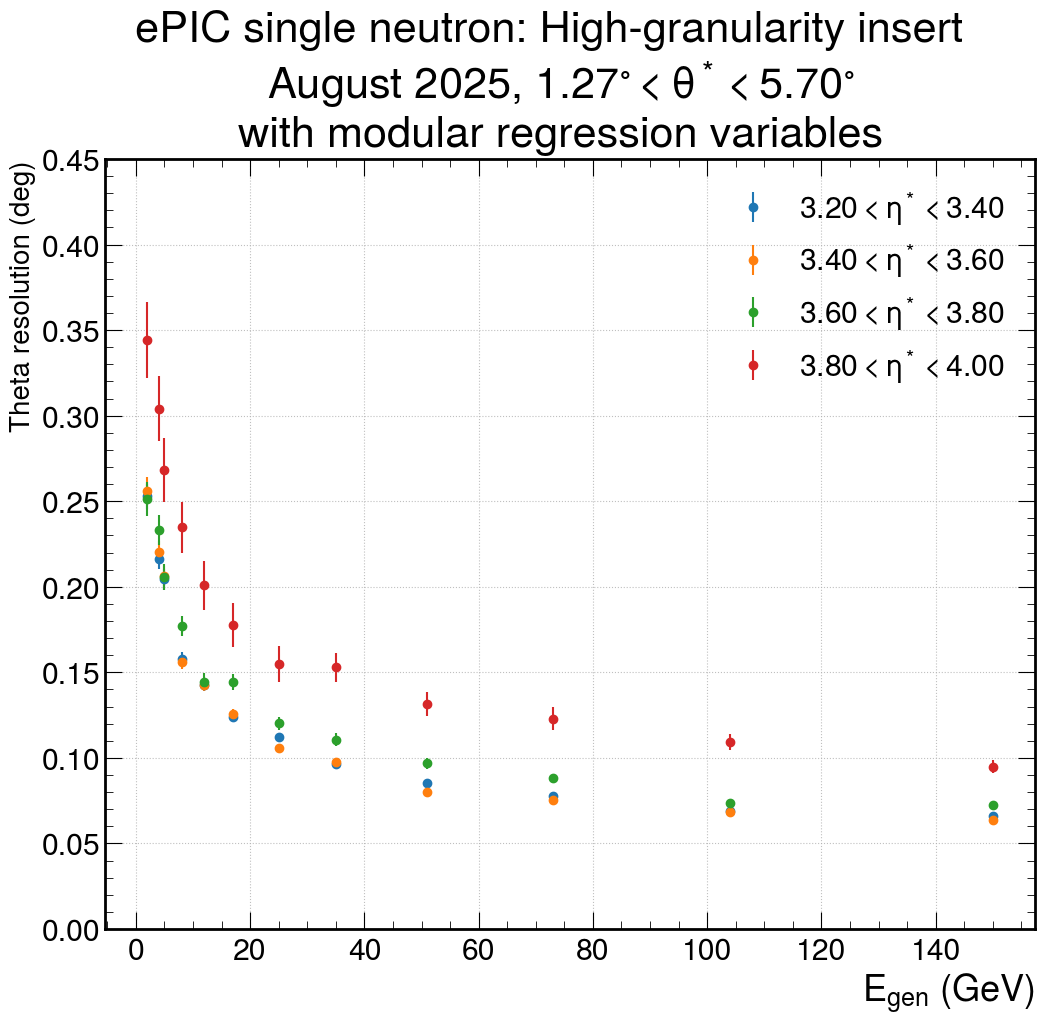

In [20]:
fig = plt.figure(figsize=(12,10))
fig.set_facecolor('w')

lower_energy_lim = 2
for i, eta_range in enumerate(eta_bins):
    truth_energy = eta_truth_energies[i]
    energy_mask = truth_energy>=lower_energy_lim
    theta_resolution = np.asarray(eta_theta_resolutions[i][0])/1000*180/np.pi
    theta_resolution_error = np.asarray(eta_theta_resolutions[i][1])/1000*180/np.pi
    plt.errorbar(truth_energy[energy_mask],
                    theta_resolution[energy_mask],
                    yerr = theta_resolution_error[energy_mask],
                    marker='o',
                    linestyle='none',
                    label = f"${eta_range[0]:.2f}<\eta^*<{eta_range[1]:.2f}$")
    

plt.legend()
plt.ylabel("Theta resolution (deg)",  fontsize=20)
plt.xlabel("$E_{gen}$ (GeV)")
plt.ylim(0, .45)
plt.grid()
if granularity=="high_granularity":
    if theta_mask:
        plt.suptitle(f"ePIC single neutron: High-granularity insert \n {date}, ${theta_low:.2f}^{{\circ}}<\\theta^*<{theta_high:.2f}^{{\circ}}$\n with  ${2.3:.2f}^{{\circ}}<\\theta^*<{4.25:.2f}^{{\circ}}$ mask", y=1.03)
    else:
        plt.suptitle(f"ePIC single neutron: High-granularity insert \n {date}, ${theta_low:.2f}^{{\circ}}<\\theta^*<{theta_high:.2f}^{{\circ}}$\n with modular regression variables", y=1.03)
else:
    if theta_mask:
        plt.suptitle(f"ePIC single neutron: Low-granularity insert \n {date}, ${theta_low:.2f}^{{\circ}}<\\theta^*<{theta_high:.2f}^{{\circ}}$\n with  ${2.3:.2f}^{{\circ}}<\\theta^*<{4.25:.2f}^{{\circ}}$ mask", y=1.03)
    else:
        plt.suptitle(f"ePIC single neutron: Low-granularity insert \n {date}, ${theta_low:.2f}^{{\circ}}<\\theta^*<{theta_high:.2f}^{{\circ}}$", y=1.01)

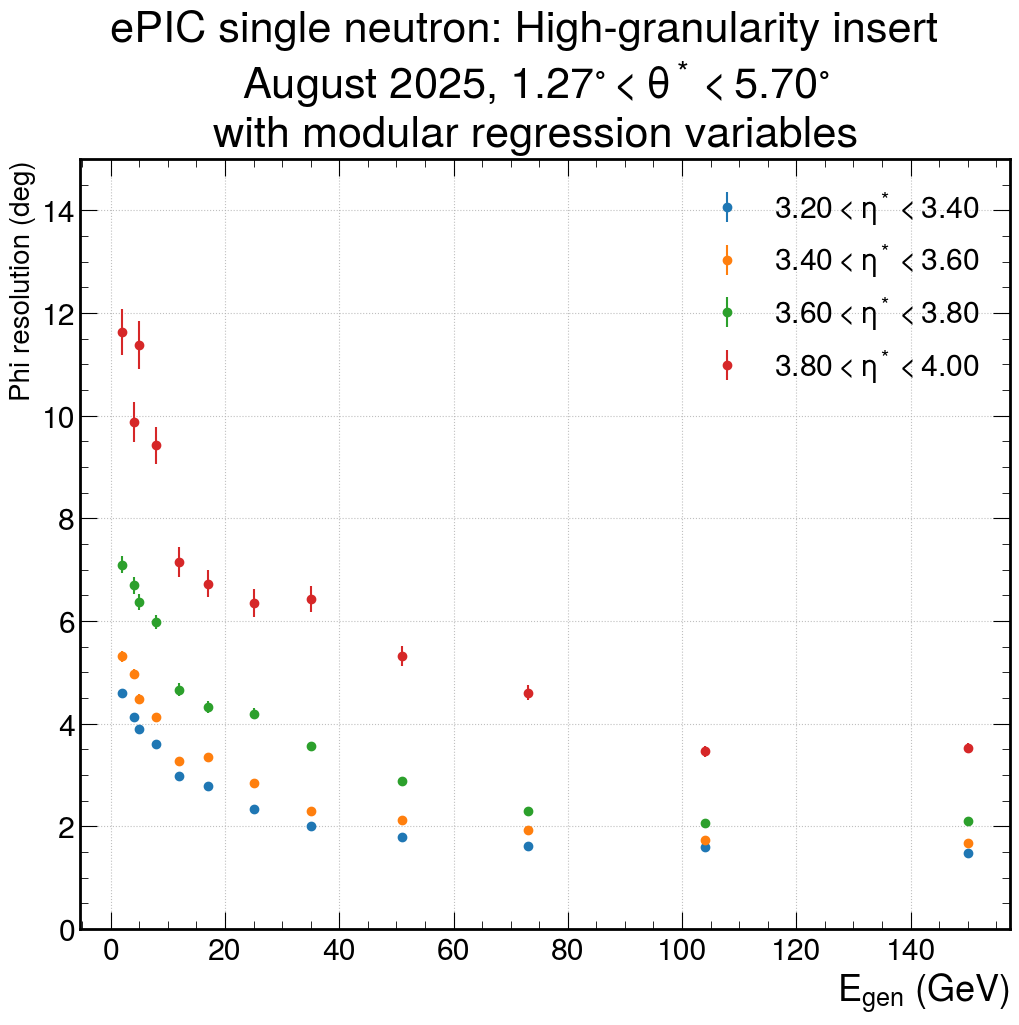

In [21]:
fig = plt.figure(figsize=(12,10))
fig.set_facecolor('w')

lower_energy_lim = 2
for i, eta_range in enumerate(eta_bins):
    truth_energy = eta_truth_energies[i]
    energy_mask = truth_energy>=lower_energy_lim
    phi_resolution = np.asarray(eta_phi_resolutions[i][0])*180/np.pi
    phi_resolution_error = np.asarray(eta_phi_resolutions[i][1])*180/np.pi
    plt.errorbar(truth_energy[energy_mask],
                    phi_resolution[energy_mask],
                    yerr = phi_resolution_error[energy_mask],
                    marker='o',
                    linestyle='none',
                    label = f"${eta_range[0]:.2f}<\eta^*<{eta_range[1]:.2f}$")
    

plt.legend()
plt.ylabel("Phi resolution (deg)",  fontsize=20)
plt.xlabel("$E_{gen}$ (GeV)")
plt.grid()
plt.ylim(0, 15)

if granularity=="high_granularity":
    if theta_mask:
        plt.suptitle(f"ePIC single neutron: High-granularity insert \n {date}, ${theta_low:.2f}^{{\circ}}<\\theta^*<{theta_high:.2f}^{{\circ}}$\n with  ${2.3:.2f}^{{\circ}}<\\theta^*<{4.25:.2f}^{{\circ}}$ mask", y=1.03)
    else:
        plt.suptitle(f"ePIC single neutron: High-granularity insert \n {date}, ${theta_low:.2f}^{{\circ}}<\\theta^*<{theta_high:.2f}^{{\circ}}$\n with modular regression variables", y=1.03)
else:
    if theta_mask:
        plt.suptitle(f"ePIC single neutron: Low-granularity insert \n {date}, ${theta_low:.2f}^{{\circ}}<\\theta^*<{theta_high:.2f}^{{\circ}}$\n with  ${2.3:.2f}^{{\circ}}<\\theta^*<{4.25:.2f}^{{\circ}}$ mask", y=1.03)
    else:
        plt.suptitle(f"ePIC single neutron: Low-granularity insert \n {date}, ${theta_low:.2f}^{{\circ}}<\\theta^*<{theta_high:.2f}^{{\circ}}$", y=1.01)